In [76]:
import sys
import os
import importlib
import numpy as np

#Add code paths
sys.path.append(os.path.abspath("../code/part4/"))

# Ex4



In [77]:
import matplotlib.pyplot as plt
from sklearn import metrics, datasets, tree
from sklearn.model_selection import train_test_split

# 1. load 
digits = datasets.load_digits() 
X, y = digits.data, digits.target

#from sklearn.datasets import fetch_openml
#mnist = fetch_openml('mnist_784')

# partition data with train_test_split

from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, train_size=0.7,stratify=y,random_state=42)


print("train size:",len(X_train),"\ntest size:",len(X_test))

train size: 1257 
test size: 540


## Logistic Regression

In [78]:
import logistic_regression as lr
importlib.reload(lr) 

lr.train(X_train, X_test, y_train, y_test)

accuracy on testing set: 0.96


There's no loss curve ???????

## Neural Network

### a) Indicate your best parameters of the hidden layer and output size and compare the results (accuracy) with the logistic regression  Indicate the loss curve of both experiments. What is your conclusion (one sentence)?

In [84]:
layer_configs = [(10,4), (15,8), (20,10), (30,15), (40,20), (50,25)]
best_acc = 0
best_config = None
best_loss_curve = None

c:\Users\Administrador\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:781: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (2000) reached and the optimization hasn't converged yet.
  warnings.warn(


accuracy on testing set: 0.8574


c:\Users\Administrador\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:781: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (2000) reached and the optimization hasn't converged yet.
  warnings.warn(


accuracy on testing set: 0.9148


c:\Users\Administrador\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:781: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (2000) reached and the optimization hasn't converged yet.
  warnings.warn(


accuracy on testing set: 0.9463


c:\Users\Administrador\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:781: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (2000) reached and the optimization hasn't converged yet.
  warnings.warn(


accuracy on testing set: 0.9556


c:\Users\Administrador\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:781: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (2000) reached and the optimization hasn't converged yet.
  warnings.warn(


accuracy on testing set: 0.9519
accuracy on testing set: 0.9704

Best NN config: (50, 25) with Accuracy = 0.9704


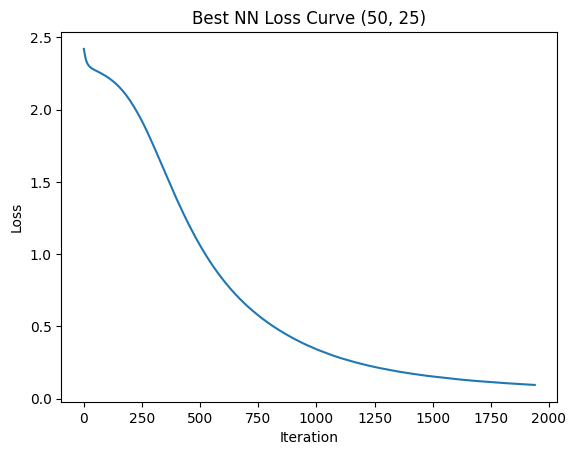

In [85]:
import neural_network as nn
importlib.reload(nn) 

for config in layer_configs:
    acc, loss_curve = nn.train(X_train, X_test, y_train, y_test, config, architecture = "logistic")
    if acc > best_acc:
        best_acc = acc
        best_config = config
        best_loss_curve = loss_curve

print(f"\nBest NN config: {best_config} with Accuracy = {best_acc:.4f}")

# Plot loss curve of the best NN
plt.plot(best_loss_curve)
plt.title(f"Best NN Loss Curve {best_config}")
plt.xlabel("Iteration")
plt.ylabel("Loss")
plt.show()

### b) Using the best architecture change for the activation function ‘identity’. Is the result still better? Indicate why not to use the identity function in the hidden layer

accuracy on testing set: 0.9574


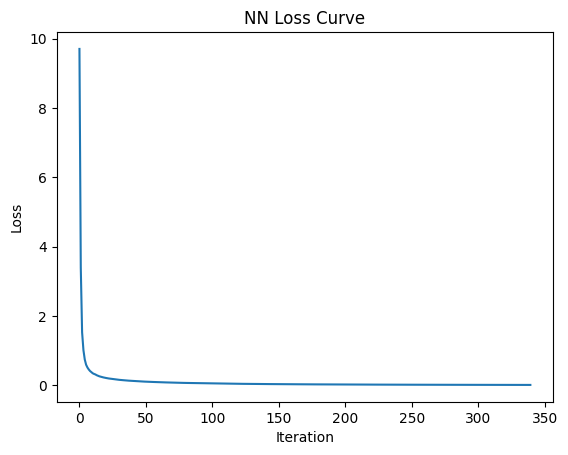

In [81]:
import neural_network as nn
importlib.reload(nn) 

_, loss_curve = nn.train(X_train, X_test, y_train, y_test, best_config, architecture = "identity")

# Plot loss curve 
plt.plot(loss_curve)
plt.title(f"NN Loss Curve")
plt.xlabel("Iteration")
plt.ylabel("Loss")
plt.show()